# Task 1 — Character-level GPT from scratch (Nikhil)

Executed record of the full Member B run (2 blocks x 8 heads, RTX 5090). All logic lives in the modules next to this notebook:

| File | Contents |
|---|---|
| `data.py` | text cleaning, `char_to_idx` / `idx_to_char`, story-level train/val split, fixed-length (x, y) windows |
| `model.py` | hand-written causal multi-head self-attention, pre-LN blocks, token + positional embeddings, LM head |
| `train.py` | AdamW, linear warm-up + cosine LR schedule, per-epoch eval, checkpoints, every Task 1 metric |
| `gen_metrics.py` | Distinct-n and repeated 4-gram rate |
| `configs/gpt_nikhil_B.yaml` | every hyperparameter for this run |

Raw data: `python task1_llm/data/download_tinystories.py` (run from repo root).

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

SRC = Path.cwd()
assert (SRC / "train.py").exists(), "run this notebook from task1_llm/member_nikhil/src"
sys.path.insert(0, str(SRC))
import train
CONFIG = SRC / "configs" / "gpt_nikhil_B.yaml"
print(CONFIG.read_text())

# Task 1 — Nikhil's GPT (Two-Member Model Plan / Member B): 2 blocks x 8 heads.
run_name: gpt_nikhil_2L8H_B
seed: 1337
device: auto            # auto = cuda > mps > cpu
write_metrics_report: true   # copy final metrics to member_nikhil/metrics_report.csv

data:
  raw_path: task1_llm/data/tinystories_raw.txt   # from task1_llm/data/download_tinystories.py
  processed_dir: data_processed
  block_size: 128        # characters of context
  n_train: 100000        # training sequences
  n_val: 10000           # validation sequences
  val_story_frac: 0.1    # stories held out for validation before chunking

model:
  d_model: 256
  n_heads: 8             # head_dim = 32
  n_layers: 2
  d_ff: 1024
  dropout: 0.10

train:
  batch_size: 64
  eval_batch_size: 256
  epochs: 12
  lr: 2.5e-4
  min_lr: 1.0e-5
  warmup_steps: 500
  weight_decay: 0.01
  grad_clip: 1.0
  spike_ratio: 1.3
  log_every: 100

generate:
  max_new_tokens: 400
  temperature: 0.9
  samples_per_prompt: 3   # plus one greedy sampl

## Model definition (no prebuilt attention modules)

In [2]:
import inspect, model
print(inspect.getsource(model.CausalSelfAttention))

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # mask[i, j] = 1 if position i may attend to position j (j <= i)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)).bool(), persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        # (B, T, C) -> (B, heads, T, head_dim)
        def split(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = split(self.q(x)), split(self.k(x)), split(self.v(x))
        scores = (q @ k.transpos

## Load the full run (set RUN_DIR = None to retrain 12 epochs, ~4 min on an RTX 5090) — the raw log is in `reproducibility/raw_logs/nikhil/`

In [3]:
RUN_DIR = SRC.parent / "outputs" / "gpt_nikhil_2L8H_B_20261001-0025"   # the committed full run
if RUN_DIR is None:
    result = train.run(CONFIG)
    out = result["out_dir"]
else:
    out = RUN_DIR
print(out.name)

gpt_nikhil_2L8H_B_20261001-0025


## Metrics

In [4]:
pd.set_option("display.max_colwidth", 80)
pd.read_csv(out / "metrics.csv")

,metric,value,notes
0,train_cross_entropy,0.824232742881775,"best ckpt, eval mode, 10k-seq train subset (nats/char)"
1,train_cross_entropy_running_last_epoch,0.8960629022789002,"mean step loss over final epoch, dropout on"
2,val_cross_entropy,0.8440268076896668,"best ckpt, 10k val sequences (nats/char)"
3,val_perplexity,2.3257133465226376,exp(val CE)
4,val_bits_per_char,1.217673289831225,val CE / ln 2
5,generalization_gap,0.01979406480789181,val CE - train CE (eval mode)
6,val_top1_next_char_accuracy,0.7320140625,NaN
7,train_top1_next_char_accuracy,0.7369328125,NaN
8,distinct_1_temp0.9,0.31265508684863524,"word-level, pooled over temperature samples"
9,distinct_2_temp0.9,0.7713567839195979,NaN


In [5]:
pd.read_csv(out / "epoch_metrics.csv").round(4)

,epoch,step,train_loss_running,train_eval_loss,train_eval_acc,val_loss,val_acc,val_ppl,val_bpc,lr_end
0,1,1563,1.8879,1.1778,0.6334,1.1862,0.6312,3.2747,1.7114,0.0002
1,2,3126,1.1668,1.0017,0.6854,1.0116,0.6823,2.7499,1.4594,0.0002
2,3,4689,1.0528,0.9399,0.7035,0.9519,0.6997,2.5906,1.3733,0.0002
3,4,6252,1.0008,0.9052,0.7136,0.9186,0.7097,2.5057,1.3252,0.0002
4,5,7815,0.9698,0.8805,0.7204,0.8950,0.7162,2.4474,1.2912,0.0002
5,6,9378,0.9478,0.8640,0.7256,0.8802,0.7210,2.4115,1.2699,0.0001
6,7,10941,0.9319,0.8505,0.7290,0.8671,0.7246,2.3800,1.2510,0.0001
7,8,12504,0.9195,0.8412,0.7318,0.8592,0.7271,2.3612,1.2395,0.0001
8,9,14067,0.9102,0.8334,0.7340,0.8520,0.7293,2.3444,1.2292,0.0000
9,10,15630,0.9031,0.8285,0.7358,0.8476,0.7308,2.3341,1.2229,0.0000


## Loss curves, gradient norm and LR schedule

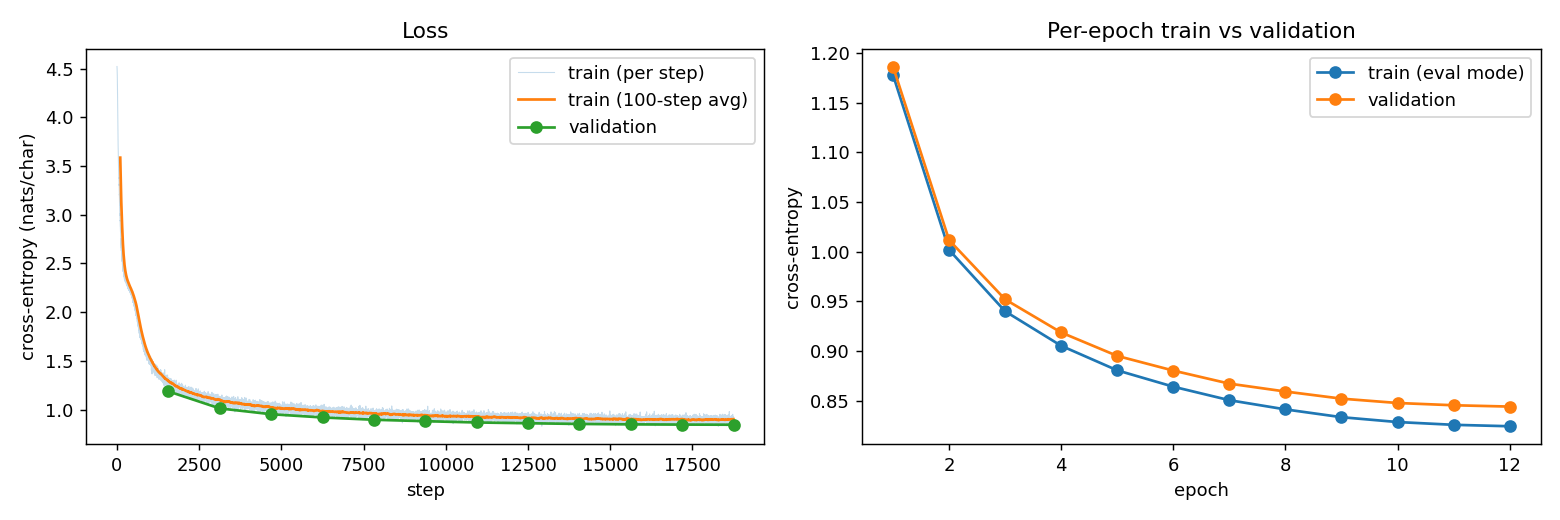

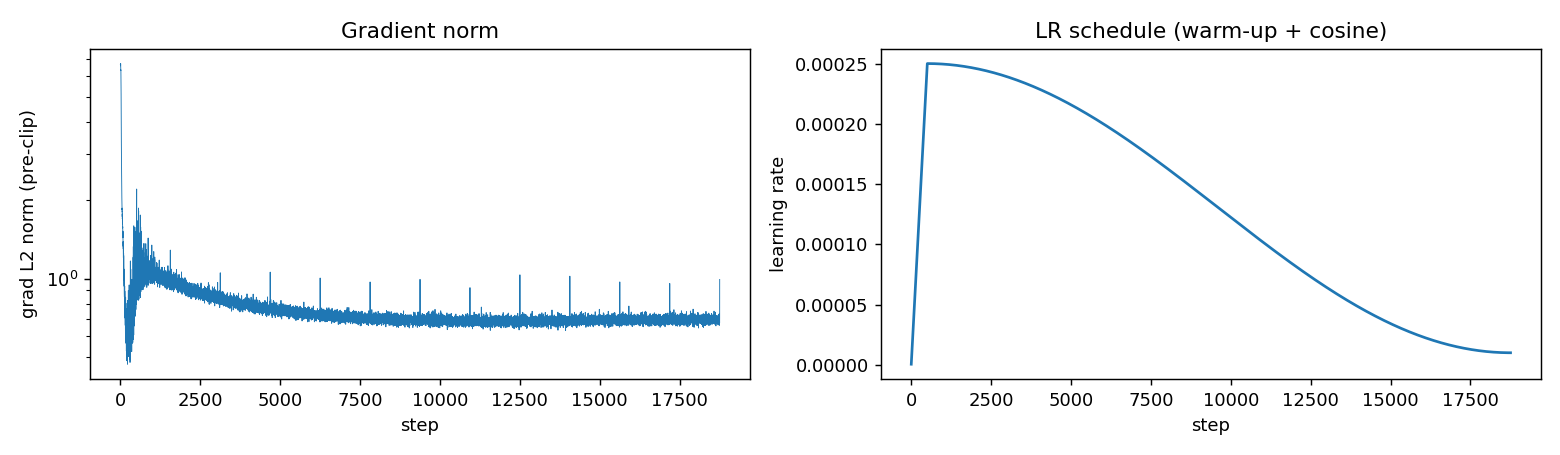

In [6]:
display(Image(out / "loss_curves.png"))
display(Image(out / "grad_norm_and_lr.png"))

## Generated samples (greedy and temperature 0.9)

In [7]:
print((out / "samples.txt").read_text())

===== [greedy] prompt: 'Once upon a time, there was a little girl named'
Once upon a time, there was a little girl named Lily. She loved to play outside in the park. One day, she went to the park with her mommy and daddy. Lily was so happy that she had to be careful with her friends.
The little girl was so happy that she had to be a good friend. She was so happy that she could help her mom find her toys and they were so happy.
The little girl was so happy that she had to be careful with her friends. She was so happ

===== [temperature=0.9] prompt: 'Once upon a time, there was a little girl named'
Once upon a time, there was a little girl named Lucy. She loved to play with her toys and told herself to others on the wave and the shiny flowers. Sometimes they both started to feel the park. They wait for the family, but it was not for the bush.
But then, they see a book or a special car and played with their toys. The tiger sprayed and had their corn feathers. Some day, the flowers comfort